#Diseases Prediction ML Model Training

#1. Data Loading


*   From Kaggle Dataset : https://www.kaggle.com/datasets/noorsaeed/medicine-recommendation-system-dataset




In [398]:

import pandas as pd

file_path = '/content/Diseases_Prediction_Dataset.csv'
df = pd.read_csv(file_path)

# OR (if uploading manually)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('Training.csv')

# Preview
print(df.head())
print("Shape:", df.shape)

   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_like_dusting  \
0           0         0             

#1.1 View First 10 Rows Of Dataset

In [403]:
from IPython.display import display

# Show small sample (first 10 rows)
display(df.head(10))

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
5,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
6,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
7,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
8,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
9,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


#2. Data Understanding & EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB
None
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue           

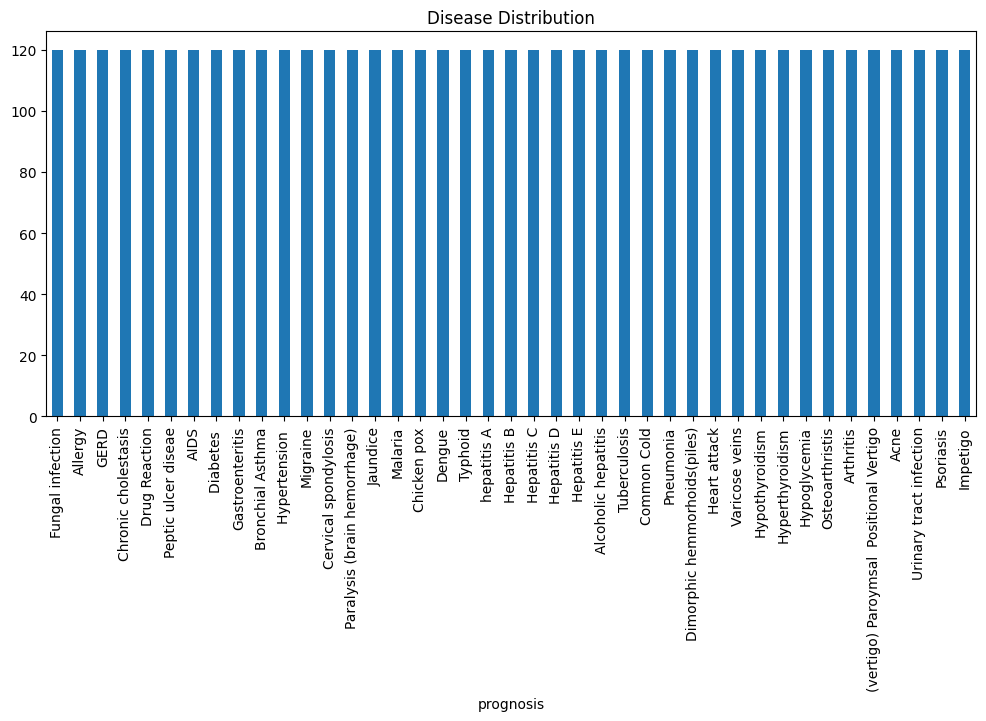

Missing values: 0


In [406]:
import numpy as np
import matplotlib.pyplot as plt

# Drop unwanted column
if 'Unnamed: 133' in df.columns:
    df = df.drop('Unnamed: 133', axis=1)

print(df.info())
print(df['prognosis'].value_counts())

# Plot class distribution
df['prognosis'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Disease Distribution")
plt.show()

# Missing values
print("Missing values:", df.isnull().sum().sum())

#2.1 Correlation Heatmap

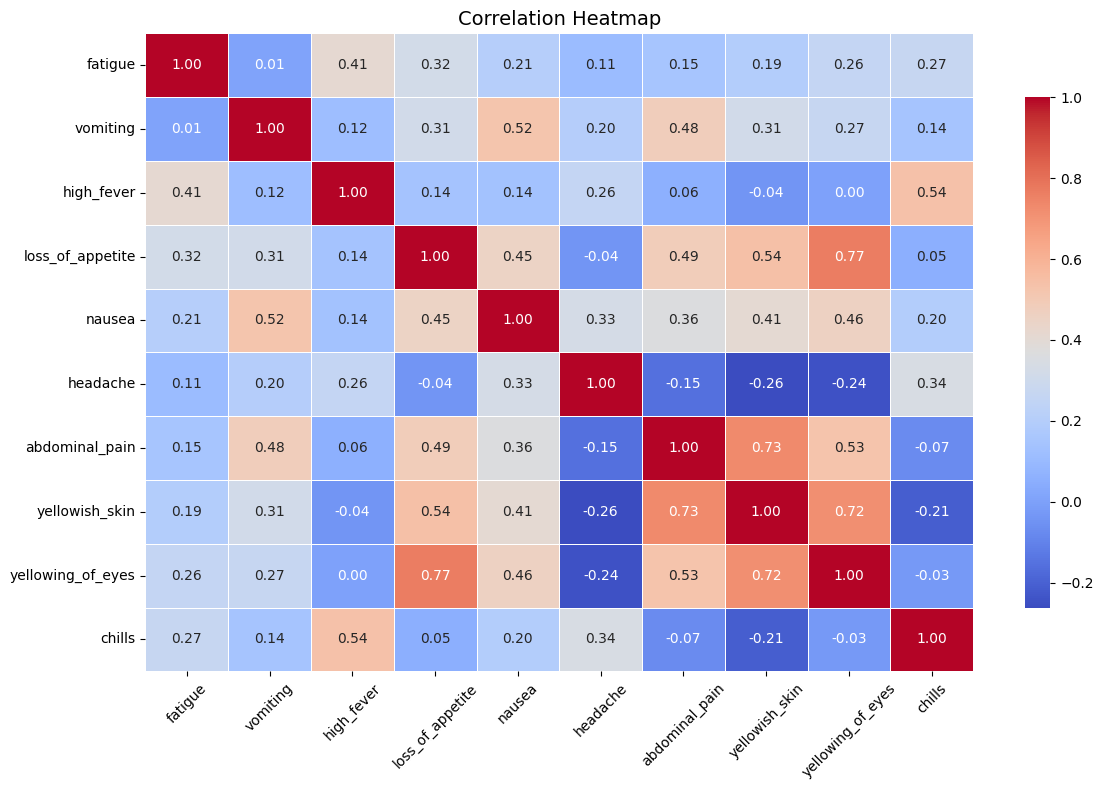

In [409]:


import seaborn as sns
import matplotlib.pyplot as plt


eda_df = df.copy()

# Remove target column
if 'prognosis' in eda_df.columns:
    eda_df = eda_df.drop('prognosis', axis=1)

# Select top 10 most frequent symptoms for clean visualization
top_cols = eda_df.sum().sort_values(ascending=False).head(10).index
eda_df = eda_df[top_cols]

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#3. Data Preprocessing

In [414]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df.drop('prognosis', axis=1)
y = df['prognosis']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#4. Feature Engineering

In [419]:
# Add symptom count feature
X_train['symptom_count'] = X_train.sum(axis=1)
X_test['symptom_count'] = X_test.sum(axis=1)

#5. Feature Selection

In [423]:
from sklearn.ensemble import RandomForestClassifier

temp_model = RandomForestClassifier(n_estimators=100, random_state=42)
temp_model.fit(X_train, y_train)

import pandas as pd
feature_importance = pd.Series(temp_model.feature_importances_, index=X_train.columns)

top_features = feature_importance.nlargest(50).index

X_train = X_train[top_features]
X_test = X_test[top_features]

#6. Model Selection & Training

In [433]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42)

#7. Model Evaluation

In [439]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))




# Accuracy in percentage
accuracypercent = accuracy_score(y_test, y_pred) * 100

print(f"Model Accuracy: {accuracypercent:.2f}%")




Accuracy: 0.9959349593495935
Model Accuracy: 99.59%


#7.1 Classification Report

In [445]:
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

# Generate classification report as dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Remove accuracy / avg rows (keep only class-wise results)
report_df = report_df.iloc[:-3]

# Add class names instead of encoded labels
report_df.index = le.inverse_transform(report_df.index.astype(int))

# Take first 10 classes
report_df = report_df.head(10)

# Round values for clean display
report_df = report_df.round(2)

# Display professionally
display(report_df.style.set_caption("Classification Report "))

,precision,recall,f1-score,support
(vertigo) Paroymsal Positional Vertigo,1.000000,1.000000,1.000000,24.000000
AIDS,1.000000,1.000000,1.000000,24.000000
Acne,1.000000,1.000000,1.000000,24.000000
Alcoholic hepatitis,1.000000,1.000000,1.000000,24.000000
Allergy,1.000000,1.000000,1.000000,24.000000
Arthritis,1.000000,0.920000,0.960000,24.000000
Bronchial Asthma,1.000000,1.000000,1.000000,24.000000
Cervical spondylosis,1.000000,1.000000,1.000000,24.000000
Chicken pox,1.000000,1.000000,1.000000,24.000000
Chronic cholestasis,1.000000,1.000000,1.000000,24.000000


#7.2 Confusion Matrix




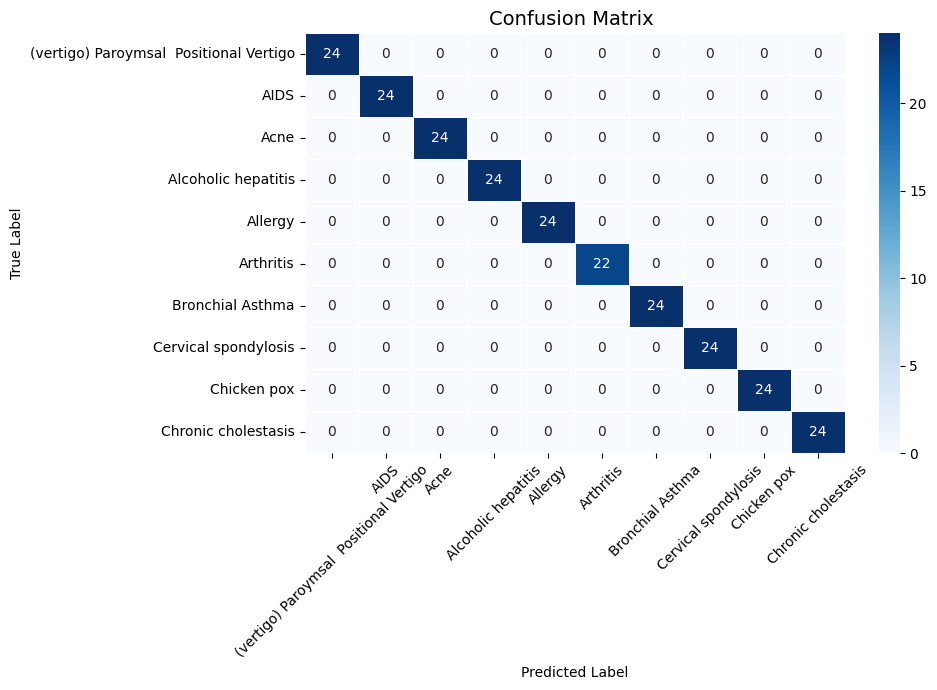

In [449]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get all class names
all_classes = le.inverse_transform(sorted(set(y_test)))

# Select first 10 classes
selected_classes = all_classes[:10]

# Convert selected class names back to encoded labels
selected_labels = le.transform(selected_classes)

# Generate confusion matrix ONLY for selected labels
cm = confusion_matrix(y_test, y_pred, labels=selected_labels)

# Create DataFrame
cm_df = pd.DataFrame(cm,
                     index=selected_classes,
                     columns=selected_classes)

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix ", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#7.3 ROC-AUC Curve

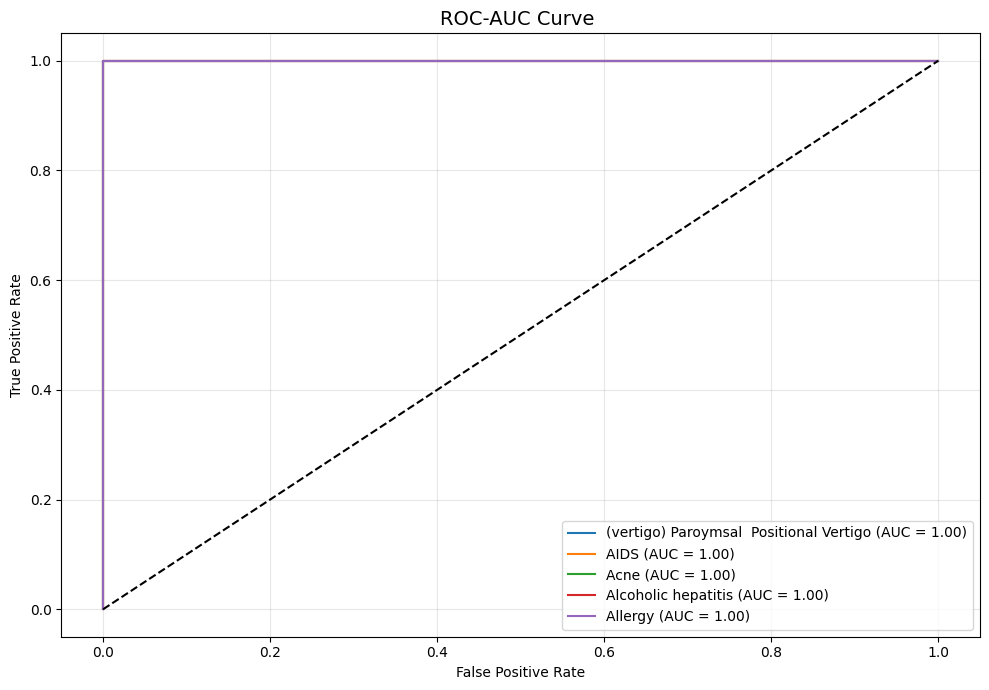

In [452]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Number of classes
n_classes = len(le.classes_)

# Binarize labels (required for ROC)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Predict probabilities
y_score = model.predict_proba(X_test)

# Plot setup
plt.figure(figsize=(10,7))

# Plot ROC curve for first 5 classes (to keep it clean)
for i in range(min(5, n_classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    class_name = le.inverse_transform([i])[0]

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], 'k--')

# Labels & title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve ", fontsize=14)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#8. Hyperparameter Tuning

In [453]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


#9. Final Model Validation

In [454]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 1.0


#10. Model Saving

In [455]:
import joblib

joblib.dump(model, 'Disease_Prediction_model.pkl')
joblib.dump(le, 'Label_encoder.pkl')

['Label_encoder.pkl']